# OCT Binary Classification — MobileNetV2 Method 3: Data Augmentation

**Approach:** Frozen MobileNetV2 base with heavy data augmentation applied to training data.
Augmentation includes rotation, flips, zoom, brightness shifts.
Pickle checkpointing for Kaggle session recovery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-21 19:10:13.937338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774120214.152603      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774120214.213289      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774120214.734927      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774120214.734974      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774120214.734977      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Data Loading

In [2]:
# Dataset paths
train_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/train'
val_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/val'
test_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/test'

for name, path in [('Train', train_dir), ('Validation', val_dir), ('Test', test_dir)]:
    if os.path.exists(path):
        print(f'\n{name} set:')
        for cls in sorted(os.listdir(path)):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                print(f'  {cls}: {len(os.listdir(cls_path))} images')


Train set:
  DISEASE: 38842 images
  NORMAL: 21052 images

Validation set:
  DISEASE: 9711 images
  NORMAL: 5263 images

Test set:
  DISEASE: 484 images
  NORMAL: 242 images


## Data Generators (WITH Augmentation)

In [3]:
# Data generators — WITH data augmentation for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    horizontal_flip=True, vertical_flip=True,
    zoom_range=0.15, brightness_range=[0.8, 1.2], fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True)
val_gen = test_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)
test_gen = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

print(f'Class mapping: {train_gen.class_indices}')
print(f'Training: {train_gen.samples} | Validation: {val_gen.samples} | Test: {test_gen.samples}')

Found 59894 images belonging to 2 classes.
Found 14974 images belonging to 2 classes.
Found 726 images belonging to 2 classes.
Class mapping: {'DISEASE': 0, 'NORMAL': 1}
Training: 59894 | Validation: 14974 | Test: 726


## Build MobileNetV2 Model (Frozen Base)

In [4]:
# Build model with frozen base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1774120301.318984      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774120301.325331      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Training with Pickle Checkpointing

In [7]:
# Training with pickle checkpointing
EPOCHS = 15
CKPT = '/kaggle/working/mobilenetv2_m3_ckpt.pkl'
WGTS = '/kaggle/working/mobilenetv2_m2_p1_weights.weights.h5'


hist = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
start = 0

if os.path.exists(CKPT):
    with open(CKPT, 'rb') as f:
        ckpt = pickle.load(f)
    model.load_weights(WGTS)
    start = ckpt['epoch']
    hist = ckpt['history']
    print(f'Resuming from epoch {start}')

for epoch in range(start, EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    h = model.fit(train_gen, epochs=epoch+1, initial_epoch=epoch, validation_data=val_gen)
    for k in hist:
        hist[k].extend(h.history[k])
    model.save_weights(WGTS)
    with open(CKPT, 'wb') as f:
        pickle.dump({'epoch': epoch+1, 'history': hist}, f)

print(f'\nBest Val Accuracy: {max(hist["val_accuracy"])*100:.2f}%')


Epoch 1/15
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 962s 514ms/step - accuracy: 0.9300 - loss: 0.1760 - val_accuracy: 0.9506 - val_loss: 0.1330

Epoch 2/15
Epoch 2/2
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 995s 532ms/step - accuracy: 0.9354 - loss: 0.1659 - val_accuracy: 0.9495 - val_loss: 0.1350

Epoch 3/15
Epoch 3/3
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 994s 531ms/step - accuracy: 0.9353 - loss: 0.1621 - val_accuracy: 0.9516 - val_loss: 0.1307

Epoch 4/15
Epoch 4/4
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 989s 528ms/step - accuracy: 0.9380 - loss: 0.1561 - val_accuracy: 0.9492 - val_loss: 0.1368

Epoch 5/15
Epoch 5/5
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 982s 524ms/step - accuracy: 0.9402 - loss: 0.1510 - val_accuracy: 0.9510 - val_loss: 0.1256

Epoch 6/15
Epoch 6/6
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 980s 523ms/step - accuracy: 0.9405 - loss: 0.1524 - val_accuracy: 0.9539 - val_loss: 0.1193

Epoch 7/15
Epoch 7/7
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 986s 526ms/step - accuracy: 0.9414 - loss: 0.1487 - val_accuracy: 0.9507 - val_loss: 0.

## Training Curves

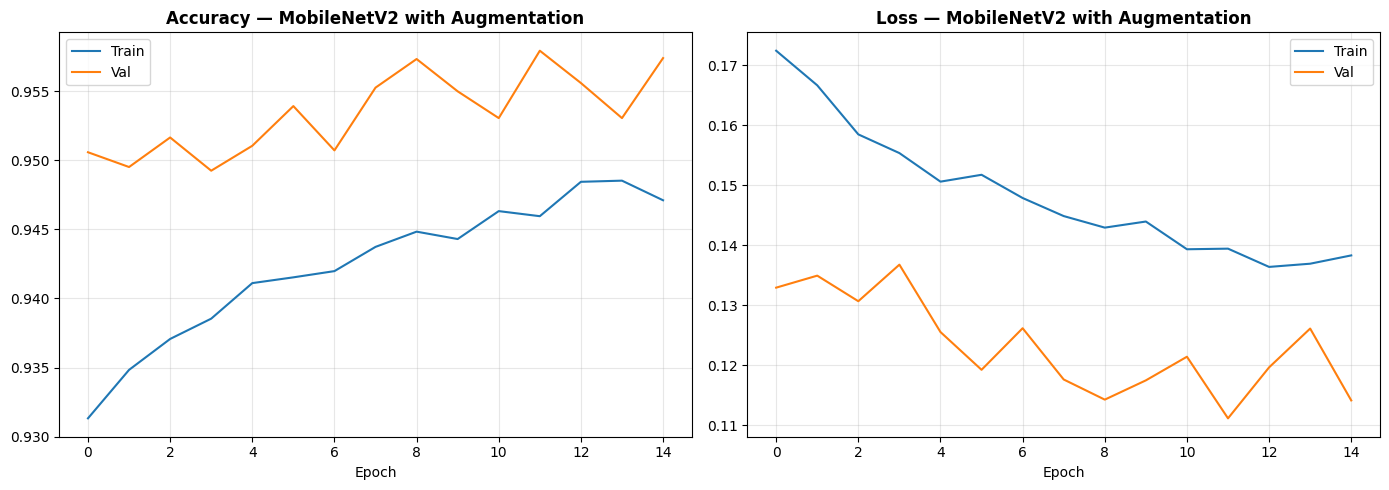

In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist['accuracy'], label='Train'); ax1.plot(hist['val_accuracy'], label='Val')
ax1.set_title('Accuracy — MobileNetV2 with Augmentation', fontweight='bold'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(hist['loss'], label='Train'); ax2.plot(hist['val_loss'], label='Val')
ax2.set_title('Loss — MobileNetV2 with Augmentation', fontweight='bold'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Evaluation

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 395ms/step - accuracy: 0.9865 - loss: 0.0416

Test Accuracy: 98.21%
Test Loss: 0.0543
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step


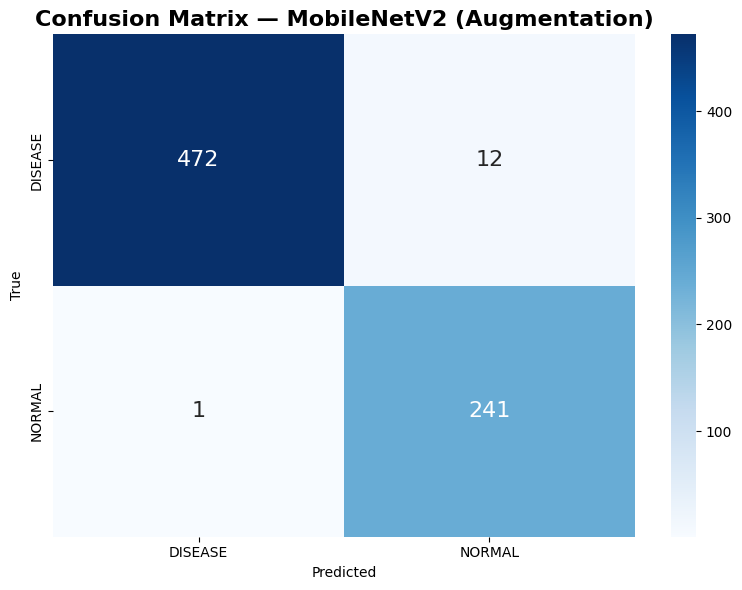

              precision    recall  f1-score   support

     DISEASE       1.00      0.98      0.99       484
      NORMAL       0.95      1.00      0.97       242

    accuracy                           0.98       726
   macro avg       0.98      0.99      0.98       726
weighted avg       0.98      0.98      0.98       726



In [9]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

# Confusion Matrix
test_gen.reset()
y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 16})
plt.title('Confusion Matrix — MobileNetV2 (Augmentation)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


/tmp/ipykernel_55/4283720286.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i] > 0.5)]


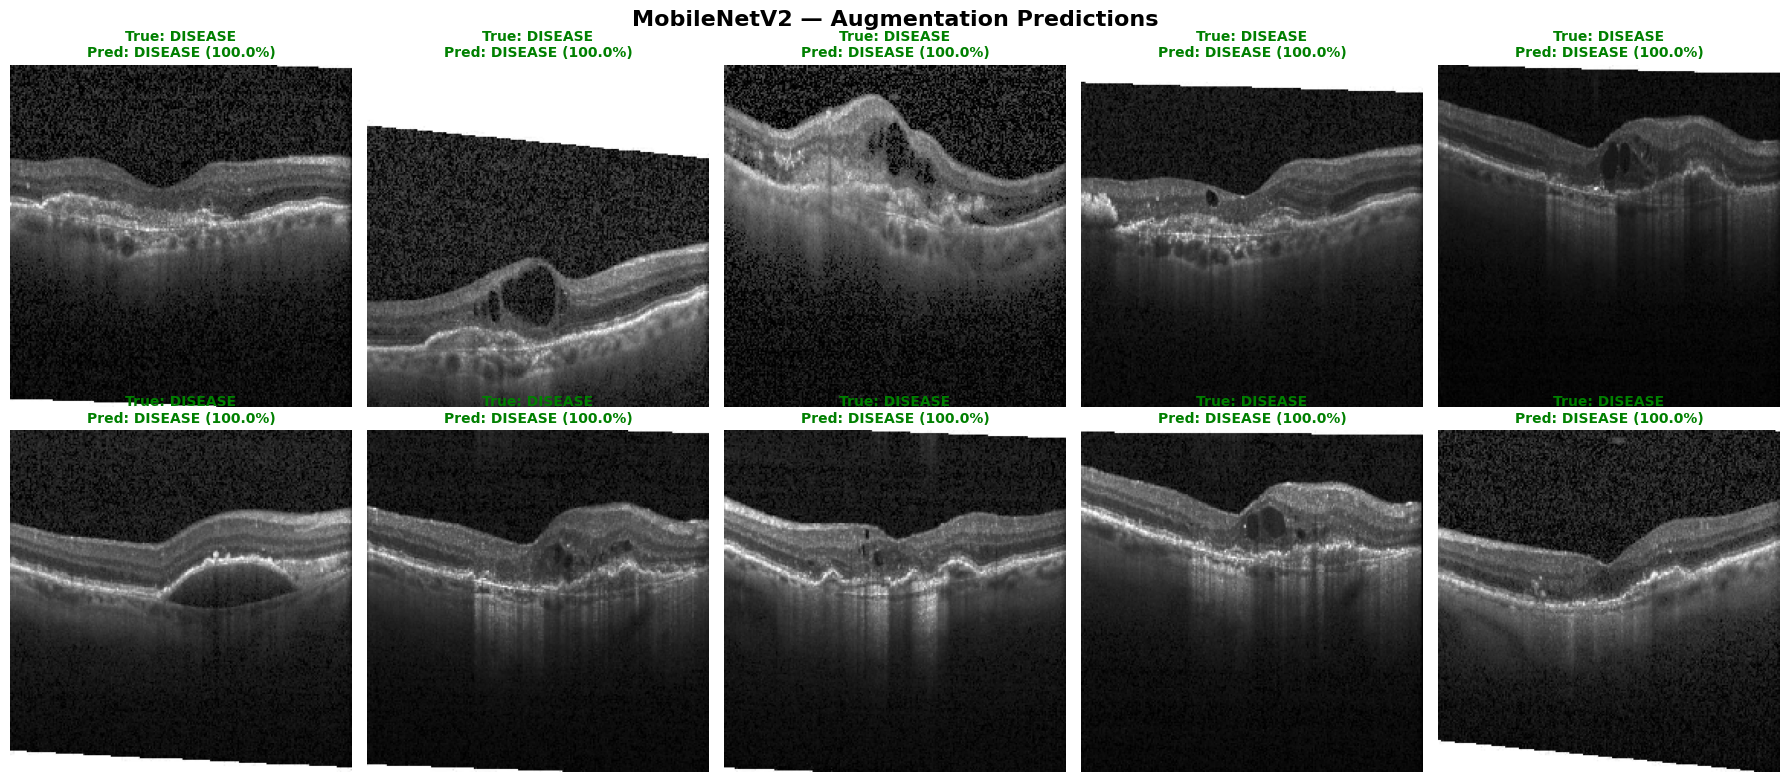

In [10]:
# Visualize predictions
test_gen.reset()
images, labels = next(test_gen)
predictions = model.predict(images)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(predictions[i] > 0.5)]
    confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1%})', fontsize=10, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('MobileNetV2 — Augmentation Predictions', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Save Model

In [11]:
model.save('mobilenetv2_method3_augmented.keras')
print('Model saved as mobilenetv2_method3_augmented.keras')

Model saved as mobilenetv2_method3_augmented.keras
